<a href="https://colab.research.google.com/github/catarina1532/pml/blob/main/MNIST_ResNet18_FineTuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Fine-tuning a Pre-trained CNN on MNIST with PyTorch

This notebook demonstrates how to fine-tune a pre-trained convolutional neural network (CNN) for handwritten digit classification using the MNIST dataset. A pre-trained ResNet18 model is adapted to recognize the ten digit classes (0–9) and subsequently saved for deployment in a Hugging Face Space using Gradio.

***prompt:*** Create a PyTorch script to fine-tune a pre-trained convolutional neural network for the MNIST data set.

###1. Import Necessary Libraries

The required libraries are imported for deep learning, data handling, visualization, and model training. PyTorch and Torchvision are used for model development and dataset management, while Matplotlib is used to visualize training performance.

In [1]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

###2. Device Configuration

The notebook automatically detects whether a GPU is available and uses it to accelerate training. If no GPU is available, training is performed on the CPU.

In [2]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


###3. Data Transformations

The MNIST dataset consists of 28×28 grayscale images. Since the pre-trained ResNet18 model expects 224×224 RGB images, several transformations are applied: resize images from 28×28 to 224×224 pixels, convert images to PyTorch tensors, normalize pixel values using standard MNIST statistics and replicate the single grayscale channel three times to create a 3-channel image compatible with ResNet18.

In [3]:
# Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1))
])

###4. Dataset Loading

The MNIST training and test datasets are downloaded and loaded using Torchvision. The transformations defined previously are applied automatically to every image.

In [4]:
# Datasets
train_dataset = datasets.MNIST(
    "./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    "./data",
    train=False,
    download=True,
    transform=transform
)

###5. Data Loaders

DataLoaders are created to efficiently feed images to the neural network during training and evaluation. The training data is shuffled at each epoch, while the test data is kept in a fixed order.

In [5]:
# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

###6. Loading a Pre-trained ResNet18 Model

A ResNet18 model pre-trained on the ImageNet dataset is loaded. Transfer learning allows the model to leverage features learned from a large image dataset, reducing training time and improving performance.

In [6]:
# Load pretrained ResNet18
model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

###7. Replacing the Final Classification Layer

The original ResNet18 model is designed to classify 1000 ImageNet categories. To adapt it to MNIST, the final fully connected layer is replaced with a new layer containing 10 output neurons, corresponding to the ten digit classes (0–9).

In [7]:
# Replace final layer
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)

model = model.to(device)

###8. Loss Function and Optimizer

The Cross-Entropy Loss function is used because the task is a multi-class classification problem. The Adam optimizer is selected to update the model parameters during training with a learning rate of 0.001.

In [8]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

num_epochs = 5

###9. Training Function

The training function performs one complete training epoch. For each batch of images: a forward pass computes predictions, the loss is calculated, backpropagation computes gradients and the model weights are updated using the optimizer. Training loss and accuracy are calculated and reported after each epoch.

In [9]:
# Training function
def train_model(model, criterion, optimizer,
                train_loader, device, epoch):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for data, target in train_loader:

        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()

        outputs = model(data)

        loss = criterion(outputs, target)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * data.size(0)

        _, predicted = torch.max(outputs, 1)

        total += target.size(0)

        correct += (predicted == target).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"Loss={epoch_loss:.4f} "
        f"Acc={epoch_acc:.4f}"
    )

    return epoch_loss, epoch_acc

###10. Evaluation Function

The evaluation function measures model performance on the test dataset. Gradients are disabled during evaluation to improve efficiency. Test loss and classification accuracy are computed without modifying the model parameters.

In [10]:
# Evaluation function
def evaluate_model(model, criterion,
                   test_loader, device):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for data, target in test_loader:

            data = data.to(device)
            target = target.to(device)

            outputs = model(data)

            loss = criterion(outputs, target)

            running_loss += loss.item() * data.size(0)

            _, predicted = torch.max(outputs, 1)

            total += target.size(0)

            correct += (predicted == target).sum().item()

    loss = running_loss / total
    acc = correct / total

    print(
        f"Test Loss={loss:.4f} "
        f"Test Accuracy={acc:.4f}"
    )

    return loss, acc

###11. Model Training

The model is trained for five epochs using the training dataset. Training loss and accuracy are recorded after each epoch to monitor learning progress.

In [11]:
# Train
train_losses = []
train_accs = []

for epoch in range(num_epochs):

    loss, acc = train_model(
        model,
        criterion,
        optimizer,
        train_loader,
        device,
        epoch
    )

    train_losses.append(loss)
    train_accs.append(acc)

print("Training finished!")

Epoch 1/5 Loss=0.0674 Acc=0.9800
Epoch 2/5 Loss=0.0348 Acc=0.9893
Epoch 3/5 Loss=0.0276 Acc=0.9915
Epoch 4/5 Loss=0.0231 Acc=0.9928
Epoch 5/5 Loss=0.0194 Acc=0.9943
Training finished!


###12. Model Testing

After training, the model is evaluated on the MNIST test dataset to estimate its generalization performance. The final test accuracy is reported.

In [12]:
# Test
test_loss, test_acc = evaluate_model(
    model,
    criterion,
    test_loader,
    device
)

print(f"Final accuracy: {test_acc:.4f}")

Test Loss=0.0242 Test Accuracy=0.9924
Final accuracy: 0.9924


###13. Saving the Trained Model

The trained model weights are saved as: `mnist_resnet18.pth`. This file is later used for deployment in the Hugging Face Space, where the model is loaded for inference through a Gradio interface.

In [13]:
# Save model
torch.save(
    model.state_dict(),
    "mnist_resnet18.pth"
)

print("Model saved as mnist_resnet18.pth")

Model saved as mnist_resnet18.pth


###14. Training Performance Visualization

Finally, training loss and accuracy are plotted across epochs. These visualizations provide insight into the learning process and help verify that the model converges appropriately during fine-tuning.

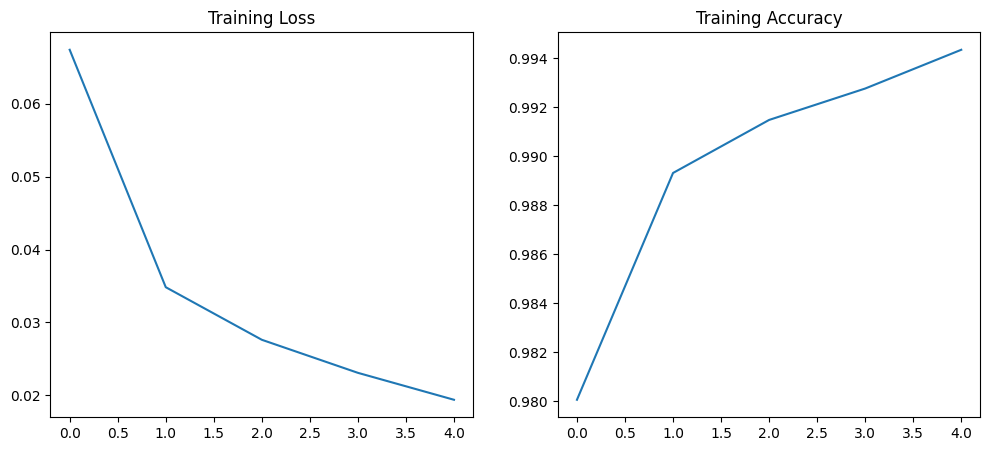

In [14]:
# Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Training Loss")

plt.subplot(1,2,2)
plt.plot(train_accs)
plt.title("Training Accuracy")

plt.show()